# Let's see Eigenvectors of Random 2D data

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Generate Random 2D Data

In [2]:
np.random.seed(42)
X = np.random.multivariate_normal(mean=[0, 0], cov=[[5, 2], [2, 4]], size=200)

print(f"Generated Data Shape: {X.shape}\n")
print(f"First 5 Data Points:\n{X[:5]}\n")
print(f"Mean of Data: {X.mean(axis=0)}\n")
print(f"Covariance Matrix Used:\n{[[5, 2], [2, 4]]}")

Generated Data Shape: (200, 2)

First 5 Data Points:
[[-0.8700089  -0.95320467]
 [-2.77133216  0.85355908]
 [ 0.69776796  0.08094044]
 [-3.92598158 -1.54491085]
 [ 0.42648332  1.40788068]]

Mean of Data: [-0.05004865  0.03770262]

Covariance Matrix Used:
[[5, 2], [2, 4]]


## Compute Eigenvectors and Eigenvalues

In [3]:
cov_matrix = np.cov(X.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# We are ckehking eigenpairs are real and taking real parts if complex
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# We need most important pairs
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print(f"Covariance Matrix:\n{cov_matrix}\n")
print(f"Eigenvalues (Variances):\n{eigenvalues}\n")
print(f"Eigenvectors (Principal Directions):\n{eigenvectors}")

Covariance Matrix:
[[4.49836304 1.84384177]
 [1.84384177 3.7915059 ]]

Eigenvalues (Variances):
[6.02234338 2.26752556]

Eigenvectors (Principal Directions):
[[ 0.77079614 -0.63708187]
 [ 0.63708187  0.77079614]]


## Plot Original Data

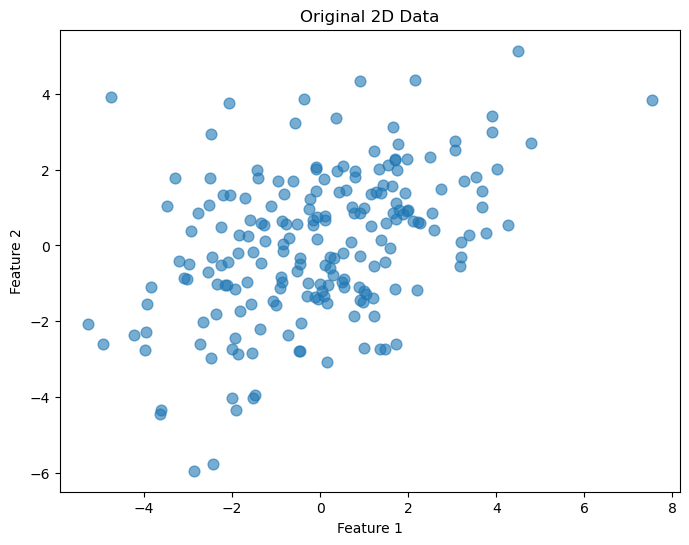

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=60)
plt.title("Original 2D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Plot 2D Data with Eigenvectors

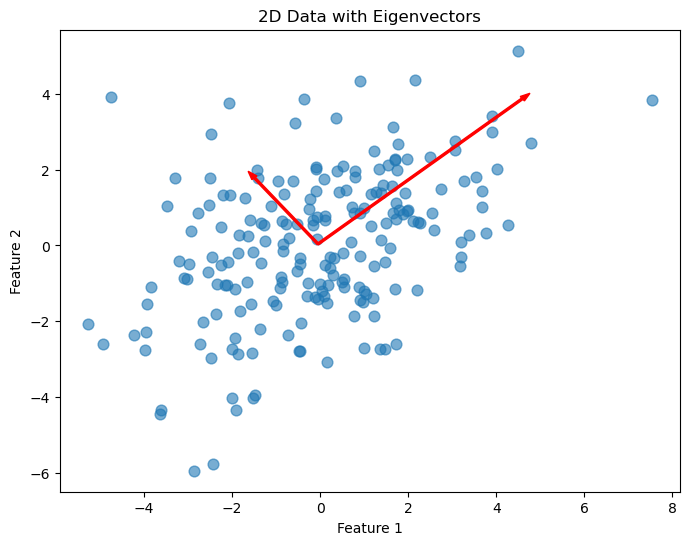

Mean of Data (Arrow Starting point): [-0.05004865  0.03770262]

Eigenvectors and Eigenvalues (Scaled for Arrows):

Component 1: Vector = [0.77079614 0.63708187], Eigenvalue = 6.022343381560964

Component 2: Vector = [-0.63708187  0.77079614], Eigenvalue = 2.267525561293351



In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=60)

mean = X.mean(axis=0)
for vec, val in zip(eigenvectors.T, eigenvalues):
    plt.arrow(mean[0], mean[1], vec[0] * val, vec[1] * val, color='red', width=0.05)

plt.title("2D Data with Eigenvectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"Mean of Data (Arrow Starting point): {mean}\n")
print(f"Eigenvectors and Eigenvalues (Scaled for Arrows):\n")
for i, (v, e) in enumerate(zip(eigenvectors.T, eigenvalues)):
    print(f"Component {i+1}: Vector = {v}, Eigenvalue = {e}\n")